# 第4章 朴素贝叶斯

1．朴素贝叶斯法是典型的生成学习方法。生成方法由训练数据学习联合概率分布
$P(X,Y)$，然后求得后验概率分布$P(Y|X)$。具体来说，利用训练数据学习$P(X|Y)$和$P(Y)$的估计，得到联合概率分布：

$$P(X,Y)＝P(Y)P(X|Y)$$

概率估计方法可以是极大似然估计或贝叶斯估计。

2．朴素贝叶斯法的基本假设是条件独立性，

$$\begin{aligned} P(X&=x | Y=c_{k} )=P\left(X^{(1)}=x^{(1)}, \cdots, X^{(n)}=x^{(n)} | Y=c_{k}\right) \\ &=\prod_{j=1}^{n} P\left(X^{(j)}=x^{(j)} | Y=c_{k}\right) \end{aligned}$$


这是一个较强的假设。由于这一假设，模型包含的条件概率的数量大为减少，朴素贝叶斯法的学习与预测大为简化。因而朴素贝叶斯法高效，且易于实现。其缺点是分类的性能不一定很高。

3．朴素贝叶斯法利用贝叶斯定理与学到的联合概率模型进行分类预测。

$$P(Y | X)=\frac{P(X, Y)}{P(X)}=\frac{P(Y) P(X | Y)}{\sum_{Y} P(Y) P(X | Y)}$$
 
将输入样本$x$分到后验概率最大的类$y$。
对于所有类别来说,p($x$)相同,则贝叶斯判断准则如下

$$y=\arg \max _{c_{k}} P\left(Y=c_{k}\right) \prod_{j=1}^{n} P\left(X_{j}=x^{(j)} | Y=c_{k}\right)$$

后验概率最大等价于0-1损失函数时的期望风险最小化。


模型：

- 高斯模型
- 多项式模型
- 伯努利模型

参考：https://machinelearningmastery.com/naive-bayes-classifier-scratch-python/

## GaussianNB 高斯朴素贝叶斯

特征的可能性被假设为高斯

概率密度函数：
$$P(x_i | y_k)=\frac{1}{\sqrt{2\pi\sigma^2_{yk}}}exp(-\frac{(x_i-\mu_{yk})^2}{2\sigma^2_{yk}})$$

数学期望(mean)：$\mu$

方差：$\sigma^2=\frac{\sum(X-\mu)^2}{N}$



### 朴素贝叶斯预测客户是否订阅定期存款

数据集来源：https://archive-beta.ics.uci.edu/dataset/222/bank+marketing

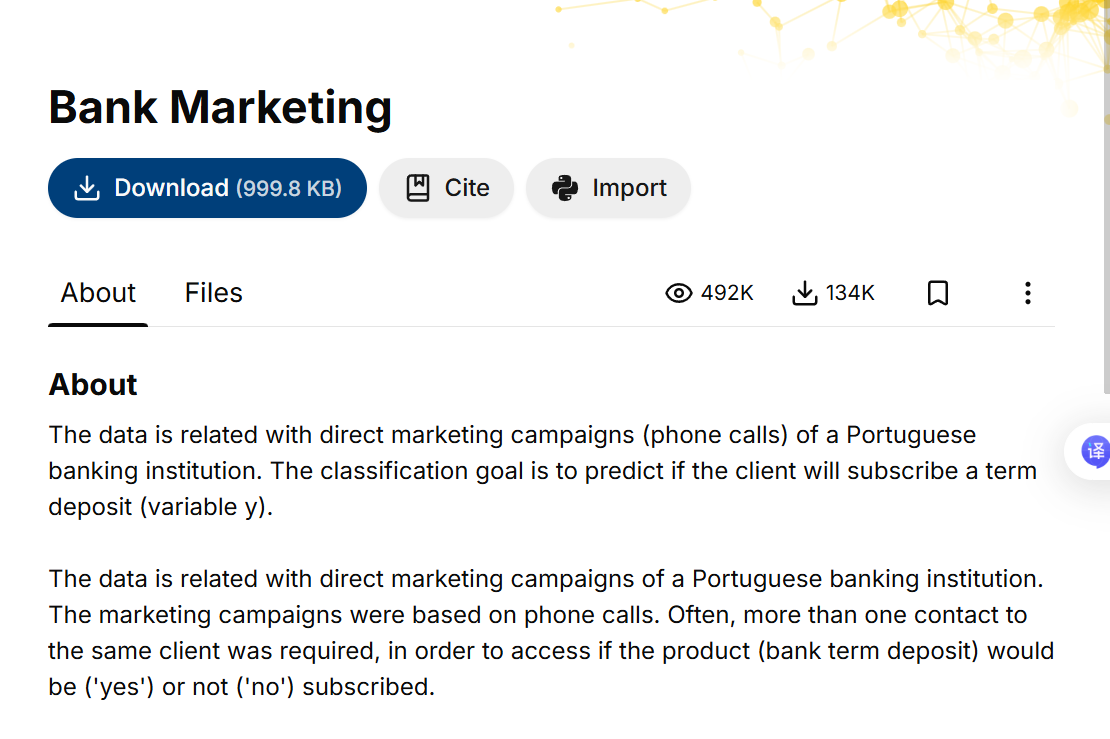


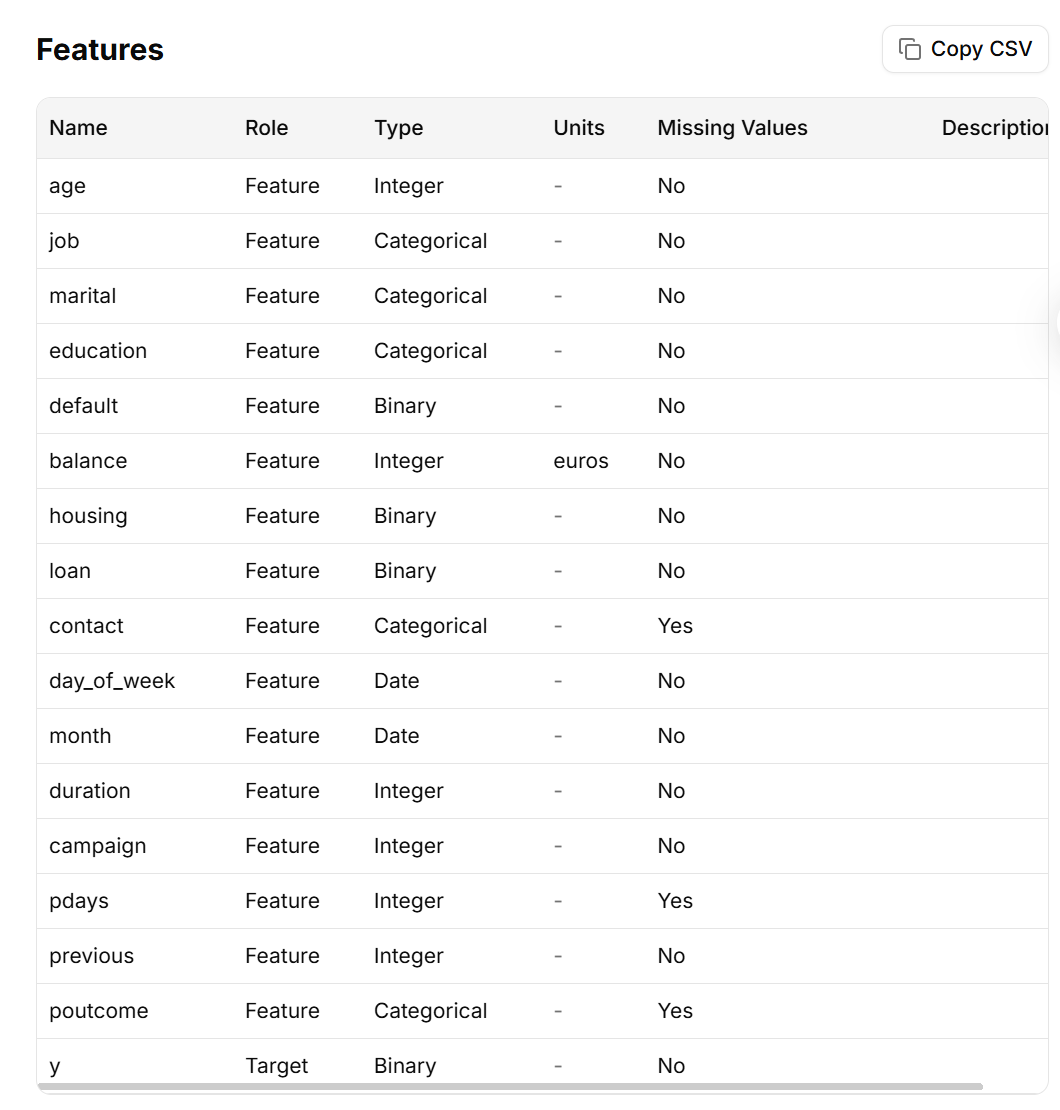

In [4]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB,BernoulliNB,MultinomialNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_curve,auc
import matplotlib.pyplot as plt

In [5]:
#读取数据，并进行数据的清洗和处理
def process_data():
    data=pd.read_csv("bank-full.csv",delimiter=";")
    data=data.drop_duplicates()
    data=data.dropna()
    #获取特征
    keys=data.keys()
    # print(keys)
    #选择是否剔除某些特征
    data = data.drop(columns=['balance',"day", "month", "pdays"])
    #编码
    le=LabelEncoder()
    for key in ["job","marital","education","default","housing",'loan',"contact","previous","poutcome",'y']:
        data[key]=le.fit_transform(data[key])
    #提取特征和标签
    X=data.iloc[:,:-1]
    Y=data.iloc[:,-1]
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.33)
    return X_train, X_test, y_train, y_test


In [6]:
#训练高斯贝叶斯分类器
def train_mdoel(X_train, X_test, y_train, y_test):
    GNB=GaussianNB()
    GNB.fit(X_train,y_train)
    y_predict=GNB.predict(X_test)
    y_pred_proba = GNB.predict_proba(X_test)[:, 1]
    #输出预测值
    print('真实值:',np.array(y_test[:20]).reshape(-1))
    print('预测值:',y_predict[:20])
    return y_predict,y_pred_proba

In [7]:
#评估模型
def score(y_test,y_predict,y_pred_proba):
    print('准确率:',accuracy_score(y_test,y_predict))
    print('精确率:',precision_score(y_test,y_predict))
    print('召回率:', recall_score(y_test, y_predict))
    #可视化
    fpr,tpr,thresholds=roc_curve(y_test,y_pred_proba)
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2,label=f'GaussianNB (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1],color='navy', lw=2, linestyle='--',label='Random Guess (AUC = 0.5)')
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve for Bank Marketing Prediction')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

真实值: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
预测值: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
准确率: 0.8691018766756032
精确率: 0.4458154506437768
召回率: 0.47458595088520844


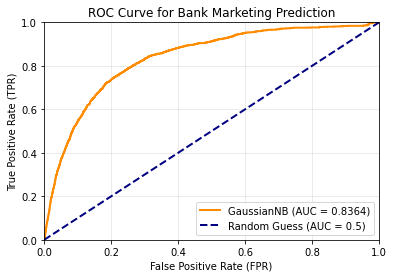

In [8]:
if __name__=='__main__':
    X_train, X_test, y_train, y_test=process_data()
    y_predict,y_pred_proba=train_mdoel(X_train, X_test, y_train, y_test)
    score(y_test,y_predict,y_pred_proba)

### 不调用scikit-learn

In [9]:
class NaiveBayes:
    def __init__(self):
        self.model = None  # 存储每个类别的均值、标准差
    # 计算均值
    @staticmethod
    def mean(X):
        X = np.array(X, dtype=np.float64)
        return sum(X) / float(len(X))

    # 计算标准差
    def stdev(self, X):
        avg = self.mean(X)
        variance = sum(pow(x - avg, 2) for x in X) / float(len(X))
        return math.sqrt(variance + 1e-6)

#     # 高斯概率密度函数,模型训练效果并不好，采用对数高斯概率
#     def gaussian_probability(self, x, mean, stdev):
#         exponent = math.exp(-(math.pow(x - mean, 2) / (2 * math.pow(stdev, 2))))
#         return (1 / (math.sqrt(2 * math.pi) * stdev)) * exponent

    # 对数高斯概率
    def gaussian_log_prob(self, x, mean, stdev):
        exponent = -((x - mean) ** 2) / (2 * stdev ** 2)
        log_p = -0.5 * math.log(2 * math.pi * stdev**2) + exponent
        return log_p
    # 计算某类所有特征的均值、标准差
    def summarize(self, train_data):
        train_data = np.array(train_data, dtype=np.float64)
        summaries = [(self.mean(i), self.stdev(i)) for i in zip(*train_data)]
        return summaries

    # 训练模型：按类别分组，计算统计量（对应sklearn的fit）
    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.int64)
        # 获取所有类别标签
        labels = np.unique(y)
        data = {label: X[y == label] for label in labels}
        #print(labels)
        # 先验概率
        total_samples = len(X)
        self.priors = {}
        for label in labels:
            count = len(data[label])
            prior = count  / total_samples 
            self.priors[label] = math.log(prior)

        # 计算每个类别的特征统计量
        self.model = {label: self.summarize(data[label]) for label in labels}

    # 计算样本属于每个类别的后验概率
    def calculate_probabilities(self, x):
        log_probs = {}
        for label, stats in self.model.items():
            logp = self.priors[label]
            for i, (mean, std) in enumerate(stats):
                logp += self.gaussian_log_prob(x[i], mean, std) 
            log_probs[label] = logp
        return log_probs
    
    # 对测试集样本预测,取对数后验概率最大的类别作为预测结果
    def predict(self, X_test):
        X_test = np.array(X_test, dtype=np.float64)
        preds = []
        for x in X_test:
            log_probs = self.calculate_probabilities(x)
            pred = max(log_probs, key=log_probs.get)
            preds.append(pred)
        return np.array(preds)
    
    #计算样本属于正例(即订阅)的概率
    def predict_proba(self, X_test):
        X_test = np.array(X_test, dtype=np.float64)
        probas = []
        for x in X_test:
            log_probs = self.calculate_probabilities(x)
            max_log = max(log_probs.values())
            exp_log = {k: math.exp(v - max_log) for k, v in log_probs.items()}
            total = sum(exp_log.values())
            prob_1 = exp_log[1] / total
            probas.append(prob_1)
        return np.array(probas)


In [10]:
def calculate_metrics(y_true, y_pred):
    y_true = np.array(y_true, dtype=np.int64)
    y_pred = np.array(y_pred, dtype=np.int64)
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    return accuracy, precision, recall

真实值: [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0]
预测值: [0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0]
准确率: 0.8760053619302949
精确率: 0.46794871794871795
召回率: 0.4614942528735632


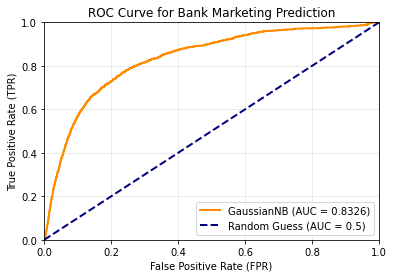

In [11]:
if __name__ == '__main__':
    X_train, X_test, y_train, y_test = process_data()
    # 初始化模型、训练
    model = NaiveBayes()
    model.fit(X_train, y_train)
    # 输出前20个结果
    y_predict = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    print('真实值:', np.array(y_test[:20]))
    print('预测值:', y_predict[:20])
    # 评估指标
    accuracy, precision, recall = calculate_metrics(y_test, y_predict)
    print('准确率:',accuracy)
    print('精确率:',precision)
    print('召回率:', recall)
    # 可视化
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'GaussianNB (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5)')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve for Bank Marketing Prediction')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()